In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Growing the 2022 TAZ Matrices to 2040 / 2050 — BU and HS (demographic reference)

Implements `docs/FORECAST_METHODOLOGY_2040_2050.md`: the 2022 layers (car, transit = bus + rail, taxi-type) are moved to each scenario-year's population and employment with trip rates, destination choice and mode split held at 2022. Per layer and scenario-year:

1. **Margins** — productions and attractions follow composite land-use indices `I = c_P·P + c_E·E` and `J = a_P·P + a_E·E` fitted on total 2022 demand (AM destinations are jobs *and* residents — schools, homes, shops): `O_i^y = O_i + ρ_i ΔI_i`, `D_j^y = D_j + σ_j ΔJ_j`, with the TAZ's own rate where it is established (index of at least 500 residents' worth in 2022 and growth factor ≤ 3) and the superzone's rate otherwise; destinations rescaled to the origin total.
2. **Seed** — the 2022 matrix plus the *increments*: established origins / destinations grow along their own 2022 row / column; small-base or transforming ones (and empty rows / columns) receive the layer's superzone pattern (`Π_AB`, reverse `Π'_BA`) spread within superzones by the targets.
3. **Furness** to the margins. Total = car + transit.

The 2022 demographic level is bridged from 2020 and BU-2025 as `X_2020 (X_2025/X_2020)^(2/5)`. When the scenario zonal files are only Git-LFS pointers, the notebook runs a **dry run** (2022 → BU-2025 growth, and a stress case with a synthetic residential conversion) to exercise every path, writes to `Output/forecast_taz/dry_run/`, and produces none of the four scenario sets.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shapefile
BLUE, ORANGE, AQUA, PURPLE, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

# ---- parameters ----
EST_MIN, EST_GMAX = 500, 3.0            # "established" TAZ: 2022 base >= 500 and growth factor <= 3
BRIDGE_POWER = 2 / 5                    # 2022 level = X2020 * (X2025/X2020)^(2/5)
SCEN = ['BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']
def is_lfs_pointer(path): return open(path, 'rb').read(40).startswith(b'version https://git-lfs')
have_scenarios = all(os.path.exists(f'Input/Demographic_Forecast/Zonal_{s}.csv') and not is_lfs_pointer(f'Input/Demographic_Forecast/Zonal_{s}.csv') for s in SCEN)
MODE = 'scenarios' if have_scenarios else 'dry_run'
OUT = 'Output/forecast_taz' if have_scenarios else 'Output/forecast_taz/dry_run'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
print('mode:', MODE, '| output:', OUT)

# ---- base layers (step 22 / 16) ----
def load_sq(path):
    m = pd.read_csv(path, index_col=0); m.index = m.index.astype(int); m.columns = m.columns.astype(int); return m
LAYERS = {'car': load_sq('Output/final_2022/car_2022_taz.csv'), 'transit': load_sq('Output/final_2022/transit_2022_taz.csv'), 'taxi': load_sq('Output/ths2017/three_mode_2022/taxi_2022_taz.csv')}
TAZ = LAYERS['car'].index.values; N = len(TAZ); assert all(m.index.equals(LAYERS['car'].index) and m.columns.equals(LAYERS['car'].columns) for m in LAYERS.values())
KEYS_LFS = 'Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv'
keys_raw = pd.read_csv('Input/taz_keys_from_shapefile.csv') if is_lfs_pointer(KEYS_LFS) else pd.read_csv(KEYS_LFS, encoding='windows-1255')
sz_of = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW'].reindex(TAZ).values
SZ = sorted(set(sz_of)); col = np.array([SZ.index(z) for z in sz_of]); M_sz = np.zeros((N, len(SZ))); M_sz[np.arange(N), col] = 1
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx'); area_of = sub_key.set_index('TAZ')['AggAreaCode']; AREA = sorted(area_of.unique())
M_area = np.zeros((N, len(AREA)))
for i, t in enumerate(TAZ):
    if t in area_of.index: M_area[i, AREA.index(area_of[t])] = 1
corridor = np.isin(TAZ, sub_key.loc[sub_key['IsLRT_Corridor'] == 1, 'TAZ'].values)
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode'); names = legend['AggAreaName']
ref = pd.read_csv('Output/ths2017/three_mode_2022/corridor_link_flows_transit_2022.csv'); SEQ = list(ref['from_code']) + [int(ref['to_code'].iloc[-1])]

# ---- demographics: 2022 bridge ----
def zonal(path):
    z = pd.read_csv(path, encoding='utf-8', encoding_errors='replace')
    return z.set_index('TAZ_ID')[['POPULATION', 'EMPL_TOT']].reindex(TAZ).fillna(0)
z20, z25 = zonal('Input/Zonal_2020.csv'), zonal('Input/Zonal_BU_2025.csv')
def bridge(x20, x25):
    return np.where(x20 > 0, x20 * np.divide(x25, x20, out=np.ones_like(x25, dtype=float), where=x20 > 0) ** BRIDGE_POWER, x25 * BRIDGE_POWER)   # zero base: linear share of the 2025 level
P22, E22 = bridge(z20['POPULATION'].values.astype(float), z25['POPULATION'].values.astype(float)), bridge(z20['EMPL_TOT'].values.astype(float), z25['EMPL_TOT'].values.astype(float))
if have_scenarios:
    SCENARIOS = {s: zonal(f'Input/Demographic_Forecast/Zonal_{s}.csv') for s in SCEN}
else:
    SCENARIOS = {'DRYRUN_BU2025': z25.astype(float)}
    stress = z25.astype(float); matam = sub_key.loc[sub_key['AggAreaName'] == 'Matam', 'TAZ'].values
    stress.loc[stress.index.isin(matam), 'POPULATION'] = 10000 / len(matam)          # synthetic residential conversion of the Matam TAZs (HS-like)
    big = stress['EMPL_TOT'].nlargest(1).index; stress.loc[big, 'EMPL_TOT'] *= 1.5   # and a large employment jump at the biggest employment TAZ
    SCENARIOS['DRYRUN_stress'] = stress
print(f"2022 bridged demographics: population {P22.sum():,.0f}, employment {E22.sum():,.0f}; scenarios: {list(SCENARIOS)}")

mode: scenarios | output: Output/forecast_taz


2022 bridged demographics: population 2,620,044, employment 995,150; scenarios: ['BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']


## 1. Margins

In [3]:
from scipy.optimize import nnls
# composite land-use indices, fitted once on total 2022 demand (car + transit + taxi): productions ~ residents + jobs, attractions ~ residents + jobs
T_tot = sum(m.values for m in LAYERS.values()); X = np.column_stack([P22, E22])
(cP, cE), _ = nnls(X, T_tot.sum(axis=1)); (aP, aE), _ = nnls(X, T_tot.sum(axis=0))
def r2(y, yhat): return 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()
print(f"production index  I = {cP:.3f}·P + {cE:.3f}·E   (R² {r2(T_tot.sum(axis=1), X @ [cP, cE]):.2f} on 2022 origins)")
print(f"attraction index  J = {aP:.3f}·P + {aE:.3f}·E   (R² {r2(T_tot.sum(axis=0), X @ [aP, aE]):.2f} on 2022 destinations; one job = {aE / max(aP, 1e-9):.2f} residents)")
I22, J22 = cP * P22 + cE * E22, aP * P22 + aE * E22
pd.DataFrame({'index': ['production I', 'attraction J'], 'per resident': [cP, aP], 'per job': [cE, aE], 'R2 on 2022': [r2(T_tot.sum(axis=1), X @ [cP, cE]), r2(T_tot.sum(axis=0), X @ [aP, aE])]}).to_csv(f'{OUT}/landuse_indices.csv', index=False, float_format='%.4f')

def margins(T, Py, Ey, layer):
    O, D = T.sum(axis=1), T.sum(axis=0)
    Iy, Jy = cP * Py + cE * Ey, aP * Py + aE * Ey
    gI = np.divide(Iy, I22, out=np.ones_like(Iy), where=I22 > 0); gJ = np.divide(Jy, J22, out=np.ones_like(Jy), where=J22 > 0)
    r_sz = (M_sz.T @ O) / np.maximum(M_sz.T @ I22, 1e-9); s_sz = (M_sz.T @ D) / np.maximum(M_sz.T @ J22, 1e-9)     # superzone rates per index unit
    est_o = (I22 >= EST_MIN * cP) & (gI <= EST_GMAX); est_d = (J22 >= EST_MIN * aP) & (gJ <= EST_GMAX)              # established: index of at least 500 residents' worth, growth <= 3x
    rho = np.where(est_o, np.divide(O, I22, out=np.zeros_like(O), where=I22 > 0), r_sz[col]); Oy = np.maximum(O + rho * (Iy - I22), 0)
    sigma = np.where(est_d, np.divide(D, J22, out=np.zeros_like(D), where=J22 > 0), s_sz[col]); Dy = np.maximum(D + sigma * (Jy - J22), 0)
    Dy = Dy * Oy.sum() / max(Dy.sum(), 1e-9)                                            # productions govern the total
    basis_o = np.where(est_o, 'own rate (multiplicative)', 'superzone rate on the increment'); basis_d = np.where(est_d, 'own rate (multiplicative)', 'superzone rate on the increment')
    tbl = pd.DataFrame({'TAZ': TAZ, 'SZ': sz_of, 'corridor': corridor, 'P_2022': P22, 'P_year': Py, 'E_2022': E22, 'E_year': Ey, 'I_2022': I22, 'I_year': Iy, 'J_2022': J22, 'J_year': Jy,
                        f'O_2022_{layer}': O, f'O_year_{layer}': Oy, 'origin basis': basis_o, f'D_2022_{layer}': D, f'D_year_{layer}': Dy, 'destination basis': basis_d})
    return Oy, Dy, tbl, est_o, est_d

production index  I = 0.506·P + 0.124·E   (R² 0.49 on 2022 origins)
attraction index  J = 0.264·P + 0.814·E   (R² 0.50 on 2022 destinations; one job = 3.08 residents)


## 2. Seed and balancing

In [4]:
def seed_matrix(T, Oy, Dy, est_o, est_d):
    O, D = T.sum(axis=1), T.sum(axis=0)
    T_sz = M_sz.T @ T @ M_sz
    Pi = np.divide(T_sz, T_sz.sum(axis=1, keepdims=True), out=np.zeros_like(T_sz), where=T_sz.sum(axis=1, keepdims=True) > 0)      # Π_AB
    Pi_r = np.divide(T_sz, T_sz.sum(axis=0, keepdims=True), out=np.zeros_like(T_sz), where=T_sz.sum(axis=0, keepdims=True) > 0)    # Π'_BA as [A, B]
    glob = T_sz.sum(axis=0); glob = glob / glob.sum()
    Pi[Pi.sum(axis=1) == 0] = glob; Pi_r[:, Pi_r.sum(axis=0) == 0] = (T_sz.sum(axis=1) / T_sz.sum())[:, None]
    D_szy = np.maximum(M_sz.T @ Dy, 1e-9); O_szy = np.maximum(M_sz.T @ Oy, 1e-9)
    wD = Dy / D_szy[col]; wO = Oy / O_szy[col]                                       # within-superzone weights
    dO = np.maximum(Oy - O, 0); dD = np.maximum(Dy - D, 0)
    own_r = est_o & (O > 0); own_c = est_d & (D > 0)
    S = T.copy()
    # origin-side growth: established origins grow along their own 2022 row; small-base / transforming origins along the layer's superzone pattern
    S[own_r] += (dO[own_r] / O[own_r])[:, None] * T[own_r]
    S[~own_r] += (dO[~own_r, None] * Pi[col[~own_r]][:, col]) * wD[None, :]
    # destination-side growth: established destinations along their own 2022 column; new / small-base destinations along the reverse pattern
    S[:, own_c] += (dD[own_c] / D[own_c])[None, :] * T[:, own_c]
    S[:, ~own_c] += (dD[None, ~own_c] * Pi_r[col][:, col[~own_c]]) * wO[:, None]
    empty_r = (S.sum(axis=1) <= 0) & (Oy > 0); S[empty_r] = (Oy[empty_r, None] * Pi[col[empty_r]][:, col]) * wD[None, :]
    empty_c = (S.sum(axis=0) <= 0) & (Dy > 0); S[:, empty_c] = (Dy[None, empty_c] * Pi_r[col][:, col[empty_c]]) * wO[:, None]
    return S
def furness(S, row_t, col_t, iters=500, tol=1e-6):
    m = S.astype(float).copy()
    for it in range(iters):
        rs = m.sum(axis=1); m *= np.divide(row_t, rs, out=np.zeros_like(row_t), where=rs > 0)[:, None]
        cs = m.sum(axis=0); m *= np.divide(col_t, cs, out=np.ones_like(col_t), where=cs > 0)[None, :]
        er = np.abs(m.sum(axis=1) - row_t).max() / max(row_t.max(), 1); ec = np.abs(m.sum(axis=0) - col_t).max() / max(col_t.max(), 1)
        if max(er, ec) < tol: break
    return m, it + 1, er, ec
def grow(T, Py, Ey, layer):
    Oy, Dy, tbl, est_o, est_d = margins(T, Py, Ey, layer); S = seed_matrix(T, Oy, Dy, est_o, est_d); Ty, it, er, ec = furness(S, Oy, Dy)
    unreachable = ((Oy > 0) & (Ty.sum(axis=1) <= 0)).sum() + ((Dy > 0) & (Ty.sum(axis=0) <= 0)).sum()
    return Ty, tbl, {'iterations': it, 'max rel margin error rows': er, 'cols': ec, 'unreachable targets': int(unreachable)}

## 3. Run all scenario-years and layers

In [5]:
r = shapefile.Reader('Input/TAZ_North/TAZ_North.shp'); cent = {}
for sh, rec in zip(r.shapes(), r.records()):
    pts = np.array(sh.points); cent[int(rec['TAZ_NUMBER'])] = pts.mean(axis=0)
XY = np.array([cent.get(t, (np.nan, np.nan)) for t in TAZ]); DIST = np.sqrt(((XY[:, None, :] - XY[None, :, :]) ** 2).sum(axis=2)) / 1000.0
np.fill_diagonal(DIST, np.nan)
def mean_len(T):
    w = T.copy(); np.fill_diagonal(w, 0); return float((w * np.nan_to_num(DIST)).sum() / max(w.sum(), 1e-9))
def link_flows(m_area):
    sub = m_area.reindex(index=SEQ, columns=SEQ).fillna(0).values; L = len(SEQ) - 1; f, b = np.zeros(L), np.zeros(L)
    for i in range(len(SEQ)):
        for j in range(len(SEQ)):
            if i < j: f[i:j] += sub[i, j]
            elif i > j: b[j:i] += sub[i, j]
    return f, b
def to_area_df(T): return pd.DataFrame(M_area.T @ T @ M_area, index=AREA, columns=AREA)
def save_sq(X, path, labels, idx):
    df_ = pd.DataFrame(X, index=labels, columns=labels); df_.index.name = idx; df_.to_csv(path, float_format='%.6g')
cls = np.where(corridor[:, None] & corridor[None, :], 'corridor→corridor', np.where(corridor[:, None] & ~corridor[None, :], 'corridor→outside', np.where(~corridor[:, None] & corridor[None, :], 'outside→corridor', 'outside→outside')))
CLASSES = ['corridor→corridor', 'corridor→outside', 'outside→corridor', 'outside→outside']

RESULTS, summary_rows, check_rows, profile_rows = {}, [], [], []
base_len = {k: mean_len(m.values) for k, m in LAYERS.items()}
for s, z in SCENARIOS.items():
    Py, Ey = z['POPULATION'].values.astype(float), z['EMPL_TOT'].values.astype(float)
    od = f'{OUT}/{s}'; os.makedirs(od, exist_ok=True); RESULTS[s] = {}; tbls = []
    for layer, T in LAYERS.items():
        Ty, tbl, chk = grow(T.values, Py, Ey, layer); RESULTS[s][layer] = Ty; tbls.append(tbl.set_index('TAZ'))
        assert (Ty >= 0).all() and np.isfinite(Ty).all()
        # superzone consistency: TAZ result reaggregated vs a plain superzone-level Furness to the same superzone margins
        T_sz = M_sz.T @ T.values @ M_sz; Osz, Dsz = M_sz.T @ tbl[f'O_year_{layer}'].values, M_sz.T @ tbl[f'D_year_{layer}'].values
        F_sz, *_ = furness(T_sz, Osz, Dsz); A_sz = M_sz.T @ Ty @ M_sz; big = F_sz > 100
        chk.update({'scenario': s, 'layer': layer, 'total 2022': T.values.sum(), 'total year': Ty.sum(), 'growth factor': Ty.sum() / T.values.sum(),
                    'mean centroid km 2022': base_len[layer], 'mean centroid km year': mean_len(Ty),
                    'SZ blocks > 100': int(big.sum()), 'SZ blocks |TAZ-reagg / SZ-Furness − 1| > 10 %': int(((np.abs(A_sz / np.where(big, F_sz, 1) - 1) > 0.10) & big).sum()),
                    'origins on superzone rate': int((tbl['origin basis'] == 'superzone rate on the increment').sum()), 'trips added on superzone rate': float((tbl[f'O_year_{layer}'] - tbl[f'O_2022_{layer}'])[tbl['origin basis'] == 'superzone rate on the increment'].clip(lower=0).sum())})
        check_rows.append(chk)
        save_sq(Ty, f'{od}/{layer}_{s}_taz.csv', TAZ, 'orig_taz'); save_sq(M_sz.T @ Ty @ M_sz, f'{od}/{layer}_{s}_sz.csv', SZ, 'origin_sz'); save_sq(M_area.T @ Ty @ M_area, f'{od}/{layer}_{s}_area.csv', AREA, 'AggAreaCode')
    tot = RESULTS[s]['car'] + RESULTS[s]['transit']; RESULTS[s]['total'] = tot
    save_sq(tot, f'{od}/total_{s}_taz.csv', TAZ, 'orig_taz'); save_sq(M_area.T @ tot @ M_area, f'{od}/total_{s}_area.csv', AREA, 'AggAreaCode')
    m = pd.concat([tbls[0][['SZ', 'corridor', 'P_2022', 'P_year', 'E_2022', 'E_year', 'I_2022', 'I_year', 'J_2022', 'J_year', 'O_2022_car', 'O_year_car', 'origin basis', 'D_2022_car', 'D_year_car', 'destination basis']],
                   tbls[1][['O_2022_transit', 'O_year_transit', 'D_2022_transit', 'D_year_transit']], tbls[2][['O_2022_taxi', 'O_year_taxi', 'D_2022_taxi', 'D_year_taxi']]], axis=1)
    m.to_csv(f'{od}/margins_{s}.csv', float_format='%.4f')
    for layer in ['car', 'transit', 'taxi', 'total']:
        Ty = RESULTS[s][layer]; base = (LAYERS['car'].values + LAYERS['transit'].values) if layer == 'total' else LAYERS[layer].values
        row = {'scenario': s, 'layer': layer, 'all 2022': base.sum(), 'all year': Ty.sum()}
        for c in CLASSES: row[f'{c} 2022'] = base[cls == c].sum(); row[f'{c} year'] = Ty[cls == c].sum()
        summary_rows.append(row)
        if layer in ('total', 'transit'):
            f, b = link_flows(to_area_df(Ty)); f0, b0 = link_flows(to_area_df(base))
            for l, (a, bb) in enumerate(zip(SEQ[:-1], SEQ[1:])):
                profile_rows.append({'scenario': s, 'layer': layer, 'link': f'{names[a]} – {names[bb]}', '1→23 2022': f0[l], '1→23 year': f[l], '23→1 2022': b0[l], '23→1 year': b[l]})
summary = pd.DataFrame(summary_rows); summary.to_csv(f'{OUT}/summary_by_class.csv', index=False, float_format='%.1f')
checks = pd.DataFrame(check_rows); checks.to_csv(f'{OUT}/checks.csv', index=False, float_format='%.5f')
profiles = pd.DataFrame(profile_rows); profiles.to_csv(f'{OUT}/corridor_link_flows_scenarios.csv', index=False, float_format='%.1f')
print(checks[['scenario', 'layer', 'total 2022', 'total year', 'growth factor', 'iterations', 'max rel margin error rows', 'cols', 'unreachable targets', 'mean centroid km 2022', 'mean centroid km year', 'SZ blocks > 100', 'SZ blocks |TAZ-reagg / SZ-Furness − 1| > 10 %', 'origins on superzone rate', 'trips added on superzone rate']].round(4).to_string(index=False))
print(); print(summary[summary['layer'].isin(['total', 'transit'])].round(0).to_string(index=False))

scenario   layer   total 2022   total year  growth factor  iterations  max rel margin error rows  cols  unreachable targets  mean centroid km 2022  mean centroid km year  SZ blocks > 100  SZ blocks |TAZ-reagg / SZ-Furness − 1| > 10 %  origins on superzone rate  trips added on superzone rate
 BU_2040     car 1353797.7474 1771486.8103         1.3085         138                     0.0000   0.0                    0                 7.3153                 7.3122              587                                            257                        129                     19450.2161
 BU_2040 transit  133703.6277  173167.3075         1.2952          61                     0.0000   0.0                    0                 9.5528                 9.2651              196                                              9                        129                      1372.6275
 BU_2040    taxi   19359.3054   25259.8658         1.3048         500                     0.1511   0.0                    0 

## 4. Where the growth lands — corridor areas, BU vs HS, trip rates

In [6]:
rows = []
for s in SCENARIOS:
    a22 = to_area_df(LAYERS['car'].values + LAYERS['transit'].values); ay = to_area_df(RESULTS[s]['total'])
    t22 = to_area_df(LAYERS['transit'].values); ty = to_area_df(RESULTS[s]['transit'])
    for a in AREA:
        rows.append({'scenario': s, 'area': a, 'name': names[a], 'on the line': a in SEQ, 'total origins 2022': a22.loc[a].sum(), 'total origins year': ay.loc[a].sum(), 'total destinations 2022': a22[a].sum(), 'total destinations year': ay[a].sum(),
                     'transit origins 2022': t22.loc[a].sum(), 'transit origins year': ty.loc[a].sum()})
by_area = pd.DataFrame(rows); by_area['origin growth'] = by_area['total origins year'] / by_area['total origins 2022'].replace(0, np.nan)
by_area.to_csv(f'{OUT}/by_area.csv', index=False, float_format='%.1f')
piv = by_area.pivot(index=['area', 'name'], columns='scenario', values='total origins year'); piv.insert(0, '2022', by_area[by_area['scenario'] == list(SCENARIOS)[0]].set_index(['area', 'name'])['total origins 2022'])
print("total trip origins by corridor area (car + transit):"); print(piv.round(0).to_string())
if have_scenarios:
    for yr in ['2040', '2050']:
        d = (piv[f'HS_{yr}'] - piv[f'BU_{yr}']); print(f"\nHS − BU {yr}, largest area differences in trip origins:"); print(d.reindex(d.abs().sort_values(ascending=False).index[:8]).round(0).to_string())
# implied trip rates per resident by superzone (car + transit origins / population)
rate_rows = []
for s in SCENARIOS:
    Py = SCENARIOS[s]['POPULATION'].values.astype(float); O22 = (LAYERS['car'].values + LAYERS['transit'].values).sum(axis=1); Oy = RESULTS[s]['total'].sum(axis=1)
    for zi, z in enumerate(SZ):
        m = col == zi; rate_rows.append({'scenario': s, 'SZ': z, 'population 2022': P22[m].sum(), 'population year': Py[m].sum(), 'trips per resident 2022': O22[m].sum() / max(P22[m].sum(), 1), 'trips per resident year': Oy[m].sum() / max(Py[m].sum(), 1)})
rates = pd.DataFrame(rate_rows); rates.to_csv(f'{OUT}/trip_rates_by_sz.csv', index=False, float_format='%.4f')
print("\nimplied AM trips per resident (car + transit origins), 2022 vs year — superzones with the largest change:")
rates['change'] = rates['trips per resident year'] / rates['trips per resident 2022'] - 1
print(rates.reindex(rates['change'].abs().sort_values(ascending=False).index[:8]).round(3).to_string(index=False))

total trip origins by corridor area (car + transit):
scenario                       2022  BU_2040  BU_2050  HS_2040  HS_2050
area name                                                              
1    TiratCarmel            16964.0  43886.0  59173.0  21562.0  22770.0
2    Matam                   1064.0   1250.0   1515.0   2438.0   3945.0
3    Neot Peres               623.0    690.0    711.0   2474.0   3661.0
4    Neve David              2844.0   2644.0   2449.0   3218.0   3445.0
5    Ein Hayam               4048.0   4737.0   5055.0   5254.0   5770.0
6    Bat Galim               3055.0   2726.0   2819.0   3879.0   4719.0
7    Kiryat Eliezer          4145.0   4187.0   4780.0   4534.0   6891.0
8    Hamoshava               3415.0   4304.0   4786.0   4195.0   4471.0
9    Lower City              2282.0   2491.0   2654.0   2669.0   2841.0
10   Hadar Carmel            3329.0   4162.0   5038.0   4395.0   5690.0
11   Namal                   1345.0   1396.0   1393.0   1386.0   1425.0
12   Neve Y

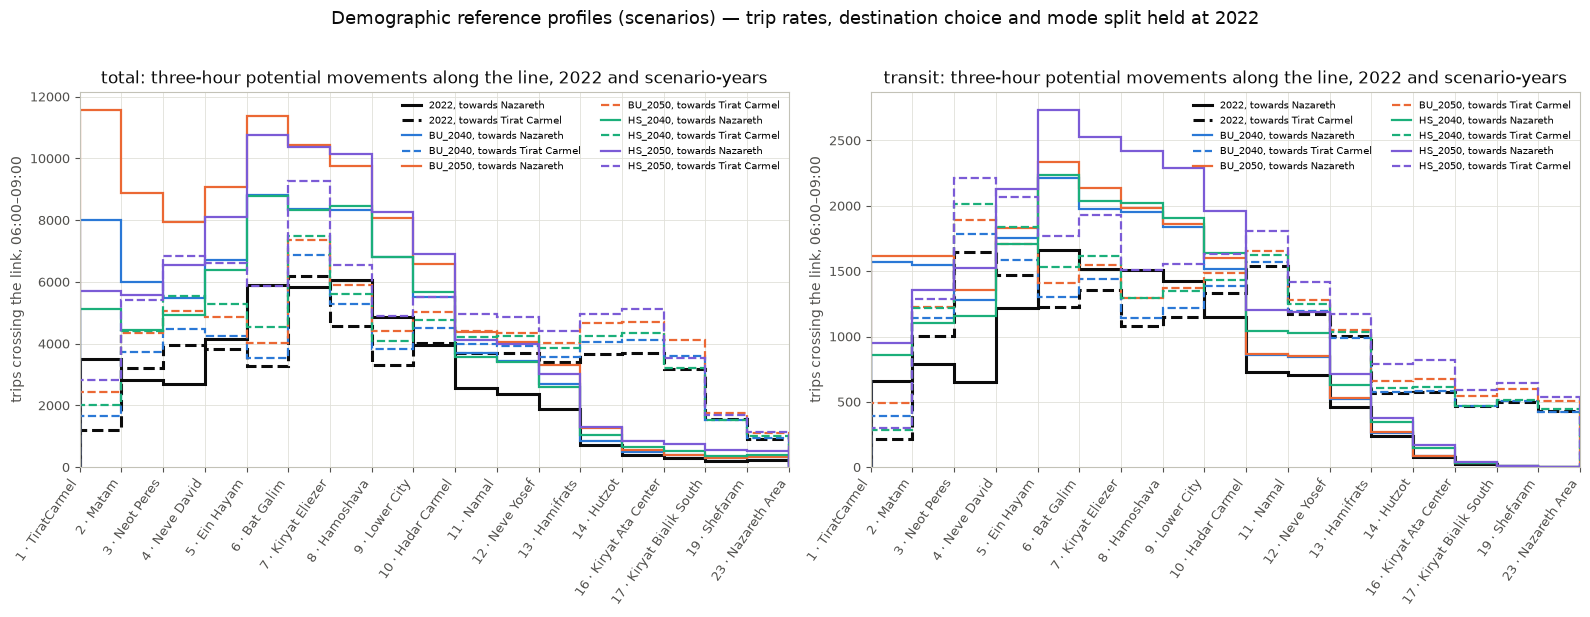

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white'); x = np.arange(len(SEQ))
for ax, layer in zip(axes, ['total', 'transit']):
    p = profiles[profiles['layer'] == layer]
    base = p[p['scenario'] == list(SCENARIOS)[0]]
    ax.stairs(base['1→23 2022'].values, x, color=INK, linewidth=2.2, label='2022, towards Nazareth'); ax.stairs(base['23→1 2022'].values, x, color=INK, linewidth=2.2, linestyle='--', label='2022, towards Tirat Carmel')
    for s, color in zip(SCENARIOS, [BLUE, ORANGE, AQUA, PURPLE]):
        q = p[p['scenario'] == s]; ax.stairs(q['1→23 year'].values, x, color=color, linewidth=1.6, label=f'{s}, towards Nazareth'); ax.stairs(q['23→1 year'].values, x, color=color, linewidth=1.6, linestyle='--', label=f'{s}, towards Tirat Carmel')
    ax.set_xticks(x); ax.set_xticklabels([f'{a} · {names[a]}' for a in SEQ], rotation=55, ha='right', fontsize=8, color=INK2); ax.set_xlim(0, len(SEQ) - 1)
    style_ax(ax, f'{layer}: three-hour potential movements along the line, 2022 and scenario-years', None, 'trips crossing the link, 06:00–09:00'); ax.legend(frameon=False, fontsize=7, ncol=2)
fig.suptitle(f'Demographic reference profiles ({MODE}) — trip rates, destination choice and mode split held at 2022', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); fig.savefig(f'Output/figures/forecast_taz_profiles_{MODE}.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## Notes

- **Demographic reference, not a forecast of LRT demand.** Trip rates per resident and per job, destination choice within each layer and the mode split of every origin are those of 2022; the four sets differ only through where population and employment are placed. Ageing, car ownership, telework, fares and service are not represented; the LRT is not in them. They are the do-nothing reference for the service-response step (`docs/LRT_CAPTURE_PLAN.md`).
- **Small-base rule.** TAZs below 500 residents (or jobs) in 2022, or growing more than three-fold, take the superzone's trip rate on the increment; the `origin basis` / `destination basis` columns of `margins_*.csv` say which rule each TAZ took, and `checks.csv` reports how many trips were added that way. The threshold and cut-off are the parameters at the top of the notebook.
- **Seed.** Only the growth increments follow the synthetic superzone pattern; existing 2022 demand keeps its cell pattern. With the synthetic terms removed (plain Furness) new-development TAZs would receive no trips at all — that is the earlier notebook's zero-cell problem the review flagged.
- **Every 2022 caveat carries forward** (METHODOLOGY §8): the bus coverage threshold, the purpose-blind TAZ allocation, missing external trips, no external validation. Corridor profiles remain three-hour potential movements; the step-20 peak-hour factors can be applied to them for a departure-hour view.
- **Dry run.** When the scenario zonal files are Git-LFS pointers the notebook runs on the BU-2025 file and a synthetic stress case and writes to `Output/forecast_taz/dry_run/`; nothing there is a scenario result.